# SEC Metadata Enhanced Analysis

Comprehensive analysis of SEC filings data found in `../output`.
- **Duplicate Analysis**: Side-by-side comparison of duplicate rows using DataFrames.
- **Phase 1 Form Coverage**: 10-K, 20-F, EX-21 stats.
- **Trends**: Time-series visualizations.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Configuration
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('ggplot')

sns.set_palette('viridis')

# Paths
OUTPUT_DIR = Path('../output')
MAIN_CSV = OUTPUT_DIR / "registrant_metadata_2025.csv"
DUPES_CSV = OUTPUT_DIR / "registrant_metadata_2025_duplicates.csv"

## 1. Load Data

In [ ]:
if MAIN_CSV.exists():
    df = pd.read_csv(MAIN_CSV, parse_dates=['filing_date'])
    print(f"Loaded Main Dataset: {len(df):,} rows")
else:
    print(f"ERROR: Main CSV not found at {MAIN_CSV}")
    df = pd.DataFrame()

## 2. Duplicate Analysis (Detailed)

Showing extensive comparison for every duplicate pair found. 
**Yellow Rows** indicate differences between the duplicate and the main entry.

In [12]:
def highlight_diff(row):
    """Highlight rows where Match is False"""
    color = 'background-color: #ffffcc' if not row['Match'] else ''
    return [color] * len(row)

if DUPES_CSV.exists():
    df_dupes = pd.read_csv(DUPES_CSV)
    print(f"Found {len(df_dupes)} duplicate entries.\n")
    
    for i, row in df_dupes.iterrows():
        cik = row['cik']
        accession = row['accession_number_nodashes']
        
        match = df[(df['cik'] == cik) & (df['accession_number_nodashes'] == accession)]
        
        if not match.empty:
            main_row = match.iloc[0]
            
            print(f"\n--- Duplicate Pair #{i+1} (CIK: {cik}) ---")
            
            comp_df = pd.DataFrame({
                'Duplicate': row,
                'Main': main_row
            })
            
            comp_df['Match'] = comp_df['Duplicate'] == comp_df['Main']
            
            # Apply styling
            styled = comp_df.style.apply(highlight_diff, axis=1)
            display(styled)
            
            if not comp_df['Match'].all():
                 print("Warning: Differences DETECTED above (Highlighted Yellow)")
        else:
            print(f"[ERROR] Orphaned duplicate #{i+1} (CIK: {cik}) not found in main index.\n")
else:
    print("No duplicates CSV found.")

Found 24 duplicate entries.


--- Duplicate Pair #1 (CIK: 825313) ---


,Duplicate,Main,Match
registrant_name,ALLIANCEBERNSTEIN HOLDING L.P.,ALLIANCEBERNSTEIN HOLDING L.P.,True
cik,825313,825313,True
accession_number,0001193125-25-032774,0001193125-25-032774,True
accession_number_nodashes,119312525032774,119312525032774,True
form_type,SC TO-T,SC 13D/A,False
filing_date,2025-02-24,2025-02-24 00:00:00,False
file_name,0001193125-25-032774.txt,0001193125-25-032774.txt,True
source_quarter,2025-Q1,2025-Q1,True
file_path,edgar/data/825313/0001193125-25-032774.txt,edgar/data/825313/0001193125-25-032774.txt,True



--- Duplicate Pair #2 (CIK: 825313) ---


,Duplicate,Main,Match
registrant_name,ALLIANCEBERNSTEIN HOLDING L.P.,ALLIANCEBERNSTEIN HOLDING L.P.,True
cik,825313,825313,True
accession_number,0001193125-25-055715,0001193125-25-055715,True
accession_number_nodashes,119312525055715,119312525055715,True
form_type,SC TO-T/A,SC 13D/A,False
filing_date,2025-03-17,2025-03-17 00:00:00,False
file_name,0001193125-25-055715.txt,0001193125-25-055715.txt,True
source_quarter,2025-Q1,2025-Q1,True
file_path,edgar/data/825313/0001193125-25-055715.txt,edgar/data/825313/0001193125-25-055715.txt,True



--- Duplicate Pair #3 (CIK: 825313) ---


...

,Duplicate,Main,Match
registrant_name,SAG Holdings Ltd,INNEOVA Holdings Ltd,False
cik,1933951,1933951,True
accession_number,0000000000-25-004206,0000000000-25-004206,True
accession_number_nodashes,25004206,25004206,True
form_type,UPLOAD,UPLOAD,True
filing_date,2025-04-21,2025-04-21 00:00:00,False
file_name,0000000000-25-004206.txt,0000000000-25-004206.txt,True
source_quarter,2025-Q2,2025-Q2,True
file_path,edgar/data/1933951/0000000000-25-004206.txt,edgar/data/1933951/0000000000-25-004206.txt,True



--- Duplicate Pair #23 (CIK: 1481241) ---


,Duplicate,Main,Match
registrant_name,Performance Shipping Inc.,Performance Shipping Inc.,True
cik,1481241,1481241,True
accession_number,0001104659-25-072410,0001104659-25-072410,True
accession_number_nodashes,110465925072410,110465925072410,True
form_type,SC TO-T/A,SC 13D/A,False
filing_date,2025-07-31,2025-07-31 00:00:00,False
file_name,0001104659-25-072410.txt,0001104659-25-072410.txt,True
source_quarter,2025-Q3,2025-Q3,True
file_path,edgar/data/1481241/0001104659-25-072410.txt,edgar/data/1481241/0001104659-25-072410.txt,True



--- Duplicate Pair #24 (CIK: 1815974) ---


,Duplicate,Main,Match
registrant_name,"Anebulo Pharmaceuticals, Inc.","Anebulo Pharmaceuticals, Inc.",True
cik,1815974,1815974,True
accession_number,0001493152-25-028828,0001493152-25-028828,True
accession_number_nodashes,149315225028828,149315225028828,True
form_type,SC TO-I,SC 13E3,False
filing_date,2025-12-22,2025-12-22 00:00:00,False
file_name,0001493152-25-028828.txt,0001493152-25-028828.txt,True
source_quarter,2025-Q4,2025-Q4,True
file_path,edgar/data/1815974/0001493152-25-028828.txt,edgar/data/1815974/0001493152-25-028828.txt,True


## 3. Phase 1 Coverage (10-K, 20-F, EX-21)

In [13]:
TARGET_FORMS = ['10-K', '20-F', 'EX-21']
df_target = df[df['form_type'].isin(TARGET_FORMS)].copy()

print(f"Total Target Filings: {len(df_target):,} ({len(df_target)/len(df)*100:.2f}%)")
print(df_target['form_type'].value_counts())

Total Target Filings: 7,768 (0.63%)
form_type
10-K    6690
20-F    1078
Name: count, dtype: int64


## 4. Visualizations

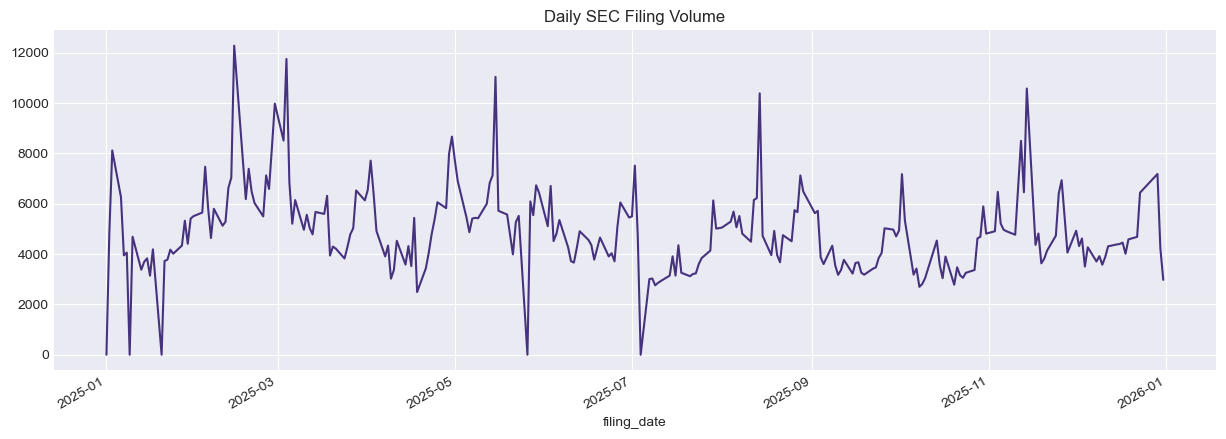

In [14]:
# Daily Volume
plt.figure(figsize=(15, 5))
df.groupby('filing_date').size().plot()
plt.title('Daily SEC Filing Volume')
plt.show()